<a href="https://colab.research.google.com/github/Kim-TH-00/AI_lab/blob/main/ai_week11_kth.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PyTorch Regression Tutorial

This tutorial demonstrates a simple linear regression using PyTorch.
We'll predict house prices using the California Housing dataset.

**Learning Objectives:**
- Understand basic PyTorch workflow
- Build a simple neural network for regression
- Train and evaluate the model
- Visualize results

## 1. Import Libraries

Import necessary libraries for data processing, model building, and visualization.

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check if CUDA is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

Using device: cpu
PyTorch version: 2.8.0+cu126


## 2. Load and Explore Data

Load the California Housing dataset and explore its structure.

In [3]:
# Load California Housing dataset
data = fetch_california_housing()

# Extract features and target
X = data.data
y = data.target

print("Dataset Information:")
print(f"Number of samples: {X.shape[0]}")
print(f"Number of features: {X.shape[1]}")
print(f"\nFeature names: {data.feature_names}")
print(f"Target: Median house value (in $100,000s)")

# Display statistics
print(f"\nTarget statistics:")
print(f"  Min: ${y.min() * 100000:.2f}")
print(f"  Max: ${y.max() * 100000:.2f}")
print(f"  Mean: ${y.mean() * 100000:.2f}")

Dataset Information:
Number of samples: 20640
Number of features: 8

Feature names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Target: Median house value (in $100,000s)

Target statistics:
  Min: $14999.00
  Max: $500001.00
  Mean: $206855.82


## 3. Data Preprocessing

Split the data into training and test sets, and normalize features for better training performance.

In [4]:
# Split data into train and test sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

# Normalize features using StandardScaler
# This helps neural networks train faster and more stably
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n✓ Data normalized (mean=0, std=1)")

Training set size: 16512 samples
Test set size: 4128 samples

✓ Data normalized (mean=0, std=1)


## 4. Convert to PyTorch Tensors

Convert NumPy arrays to PyTorch tensors and create DataLoaders for batch processing.

In [5]:
# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train_scaled)
y_train_tensor = torch.FloatTensor(y_train).reshape(-1, 1)
X_test_tensor = torch.FloatTensor(X_test_scaled)
y_test_tensor = torch.FloatTensor(y_test).reshape(-1, 1)

# Create TensorDatasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# Create DataLoaders for batch processing
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Batch size: {batch_size}")
print(f"Number of training batches: {len(train_loader)}")
print(f"Number of test batches: {len(test_loader)}")

Batch size: 64
Number of training batches: 258
Number of test batches: 65


## 5. Model Definition

Define a simple feedforward neural network for regression.

**Architecture:**
- Input layer: 8 features
- Hidden layer 1: 64 neurons with ReLU activation
- Hidden layer 2: 32 neurons with ReLU activation
- Output layer: 1 neuron (predicted house price)

In [6]:
class RegressionModel(nn.Module):
    def __init__(self, input_size, hidden_size1=64, hidden_size2=32):
        super(RegressionModel, self).__init__()

        # Define layers
        self.fc1 = nn.Linear(input_size, hidden_size1)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size1, hidden_size2)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(hidden_size2, 1)  # Output layer

    def forward(self, x):
        # Forward pass through the network
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)
        return x

# Initialize model
input_size = X_train_scaled.shape[1]  # Number of features (8)
model = RegressionModel(input_size).to(device)

print(model)
print(f"\nModel moved to: {device}")

RegressionModel(
  (fc1): Linear(in_features=8, out_features=64, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=32, out_features=1, bias=True)
)

Model moved to: cpu


## 6. Loss Function and Optimizer

Define the loss function and optimizer for training.

- **Loss Function:** Mean Squared Error (MSE) - standard for regression
- **Optimizer:** Adam - adaptive learning rate optimizer

In [7]:
# Loss function: Mean Squared Error
criterion = nn.MSELoss()

# Optimizer: Adam with learning rate 0.001
learning_rate = 0.001
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

print(f"Loss function: {criterion}")
print(f"Optimizer: Adam")
print(f"Learning rate: {learning_rate}")

Loss function: MSELoss()
Optimizer: Adam
Learning rate: 0.001


## 7. Training Loop

Train the model and track the loss over epochs.

**Training Process:**
1. Forward pass: compute predictions
2. Compute loss: compare predictions with true values
3. Backward pass: compute gradients
4. Update weights: optimize parameters

In [8]:
# Training parameters
num_epochs = 100

# Track losses for visualization
train_losses = []
test_losses = []

print("Starting training...")
print("-" * 60)

for epoch in range(num_epochs):
    # Training phase
    model.train()
    train_loss = 0.0

    for X_batch, y_batch in train_loader:
        # Move data to device (GPU if available)
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        # 1. Forward pass: compute predictions
        predictions = model(X_batch)

        # 2. Compute loss
        loss = criterion(predictions, y_batch)

        # 3. Backward pass: compute gradients
        optimizer.zero_grad()  # Clear previous gradients
        loss.backward()  # Compute new gradients

        # 4. Update weights
        optimizer.step()

        train_loss += loss.item()

    # Average training loss for this epoch
    avg_train_loss = train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Evaluation phase (no gradient computation needed)
    model.eval()
    test_loss = 0.0

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            predictions = model(X_batch)
            loss = criterion(predictions, y_batch)
            test_loss += loss.item()

    avg_test_loss = test_loss / len(test_loader)
    test_losses.append(avg_test_loss)

    # Print progress every 10 epochs
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] | "
              f"Train Loss: {avg_train_loss:.4f} | "
              f"Test Loss: {avg_test_loss:.4f}")

print("-" * 60)
print("Training complete!")

Starting training...
------------------------------------------------------------
Epoch [10/100] | Train Loss: 0.3203 | Test Loss: 0.3235
Epoch [20/100] | Train Loss: 0.2894 | Test Loss: 0.3040
Epoch [30/100] | Train Loss: 0.2750 | Test Loss: 0.3050
Epoch [40/100] | Train Loss: 0.2681 | Test Loss: 0.2861
Epoch [50/100] | Train Loss: 0.2599 | Test Loss: 0.2841
Epoch [60/100] | Train Loss: 0.2545 | Test Loss: 0.2871
Epoch [70/100] | Train Loss: 0.2516 | Test Loss: 0.2813
Epoch [80/100] | Train Loss: 0.2443 | Test Loss: 0.2721
Epoch [90/100] | Train Loss: 0.2395 | Test Loss: 0.2811
Epoch [100/100] | Train Loss: 0.2350 | Test Loss: 0.2708
------------------------------------------------------------
Training complete!


## 8. Visualize Training Progress

Plot the training and test losses to see how the model learned over time.

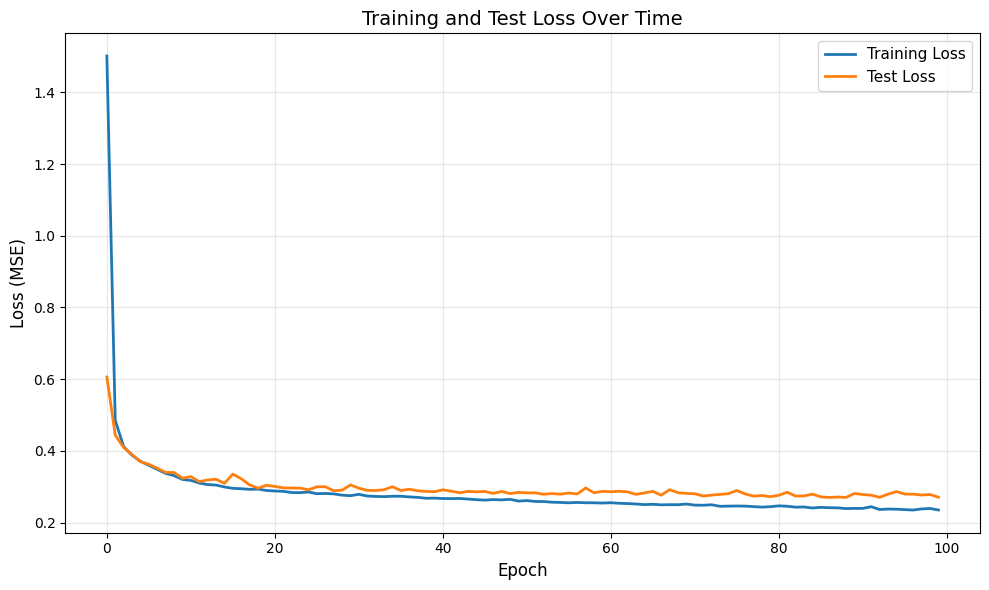

Final Training Loss: 0.2350
Final Test Loss: 0.2708


In [9]:
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss', linewidth=2)
plt.plot(test_losses, label='Test Loss', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)
plt.title('Training and Test Loss Over Time', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Final Training Loss: {train_losses[-1]:.4f}")
print(f"Final Test Loss: {test_losses[-1]:.4f}")

## 9. Model Evaluation

Evaluate the model on the test set and visualize predictions vs actual values.

In [10]:
# Make predictions on test set
model.eval()
with torch.no_grad():
    X_test_device = X_test_tensor.to(device)
    y_pred = model(X_test_device).cpu().numpy()
    y_true = y_test_tensor.numpy()

# Calculate metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse = mean_squared_error(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)
rmse = np.sqrt(mse)

print("Model Performance on Test Set:")
print("=" * 50)
print(f"Mean Squared Error (MSE):  {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R² Score: {r2:.4f}")
print("=" * 50)
print(f"\nInterpretation:")
print(f"On average, predictions are off by ${mae * 100000:.2f}")
print(f"Model explains {r2*100:.2f}% of the variance in house prices")

Model Performance on Test Set:
Mean Squared Error (MSE):  0.2713
Root Mean Squared Error (RMSE): 0.5209
Mean Absolute Error (MAE): 0.3529
R² Score: 0.7929

Interpretation:
On average, predictions are off by $35292.15
Model explains 79.29% of the variance in house prices


## 10. Visualize Predictions

Compare predicted values with actual values to see how well the model performs.

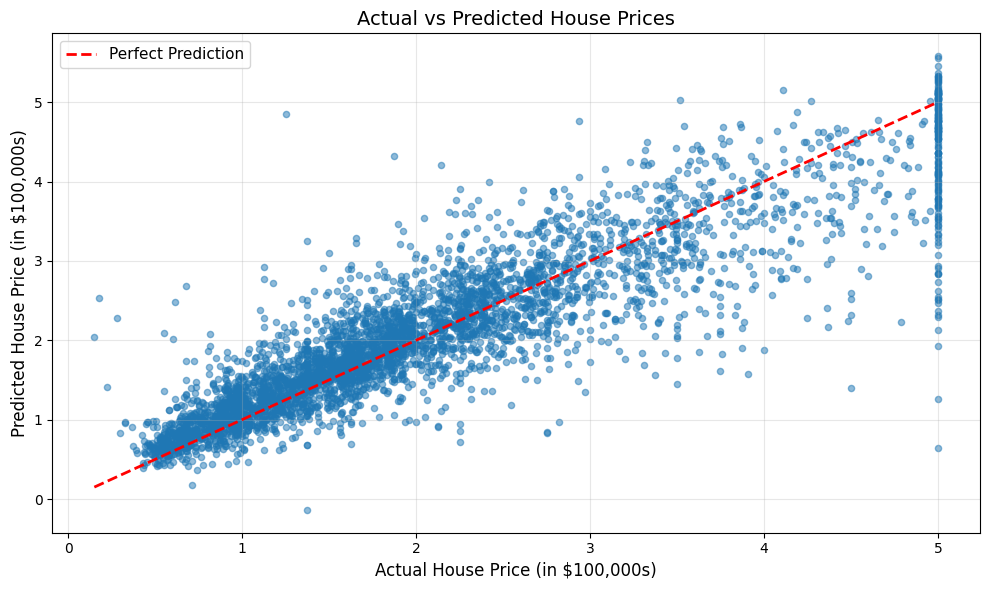


Sample Predictions (first 10 houses):
------------------------------------------------------------
      Actual |    Predicted |   Difference
------------------------------------------------------------
$    47,700 | $    56,233 | $    -8,533
$    45,800 | $    96,508 | $   -50,708
$   500,001 | $   469,646 | $    30,355
$   218,600 | $   251,313 | $   -32,713
$   278,000 | $   261,503 | $    16,497
$   158,700 | $   174,658 | $   -15,958
$   198,200 | $   229,698 | $   -31,498
$   157,500 | $   169,142 | $   -11,642
$   340,000 | $   226,781 | $   113,219
$   446,600 | $   465,063 | $   -18,463


In [11]:
# Create scatter plot of predictions vs actual values
plt.figure(figsize=(10, 6))
plt.scatter(y_true, y_pred, alpha=0.5, s=20)
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()],
         'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual House Price (in $100,000s)', fontsize=12)
plt.ylabel('Predicted House Price (in $100,000s)', fontsize=12)
plt.title('Actual vs Predicted House Prices', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Show some sample predictions
print("\nSample Predictions (first 10 houses):")
print("-" * 60)
print(f"{'Actual':>12} | {'Predicted':>12} | {'Difference':>12}")
print("-" * 60)
for i in range(min(10, len(y_true))):
    actual = y_true[i][0] * 100000
    predicted = y_pred[i][0] * 100000
    diff = actual - predicted
    print(f"${actual:>10,.0f} | ${predicted:>10,.0f} | ${diff:>10,.0f}")

## 11. Save the Model (Optional)

Save the trained model for future use.

In [12]:
# Save model
torch.save(model.state_dict(), 'house_price_model.pth')
print("✓ Model saved to 'house_price_model.pth'")

# To load the model later:
# model = RegressionModel(input_size)
# model.load_state_dict(torch.load('house_price_model.pth'))
# model.to(device)
# model.eval()

print("\nTo load this model later, use:")
print("  model = RegressionModel(input_size)")
print("  model.load_state_dict(torch.load('house_price_model.pth'))")
print("  model.to(device)")
print("  model.eval()")

✓ Model saved to 'house_price_model.pth'

To load this model later, use:
  model = RegressionModel(input_size)
  model.load_state_dict(torch.load('house_price_model.pth'))
  model.to(device)
  model.eval()


## Summary

### What We Learned:

1. **Data Preparation**: Loaded, split, and normalized data
2. **PyTorch Tensors**: Converted data to PyTorch format
3. **DataLoader**: Created batches for efficient training
4. **Neural Network**: Built a simple feedforward network
5. **Training Loop**: Implemented forward/backward passes
6. **Evaluation**: Assessed model performance with metrics
7. **Visualization**: Plotted training progress and predictions

### Key Concepts:

- **Forward Pass**: Input → Hidden Layers → Output
- **Loss Function**: Measures prediction error (MSE)
- **Backward Pass**: Computes gradients via backpropagation
- **Optimizer**: Updates weights to minimize loss (Adam)
- **Epochs**: Complete passes through training data

### Next Steps:

Try experimenting with:
- Different network architectures (more/fewer layers)
- Different activation functions
- Different optimizers (SGD, RMSprop)
- Learning rate scheduling
- Dropout for regularization

# Homework
1. Kaggle에서 regression 관련 dataset을 찾아 .csv 파일 등등을 다운받고
2. 해당 dataset을 load하여 regression을 통해 최대한 높은 regression 정확도 달성해보기

In [13]:
# 아래 이어서 코드 작성하여 결과를 포함한 .ipynb 파일을 깃허브에 커밋하여 제출하세요!

kaggle.json 파일을 업로드하세요


Saving insurance.csv to insurance.csv
mv: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Kaggle에서 데이터 다운로드 중...
Traceback (most recent call last):
  File "/usr/local/bin/kaggle", line 10, in <module>
    sys.exit(main())
             ^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/kaggle/cli.py", line 68, in main
    out = args.func(**command_args)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/kaggle/api/kaggle_api_extended.py", line 1741, in dataset_download_cli
    with self.build_kaggle_client() as kaggle:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/kaggle/api/kaggle_api_extended.py", line 688, in build_kaggle_client
    username=self.config_values['username'],
             ~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^
KeyError: 'username'
압축 해제중...
unzip:  cannot find or open insurance.zip, insurance.zip.zip or insurance.zip.ZIP.
 데

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None
 전처리 완료

 모델별 MSE 비교:
LinearRegression: 33596915.85136145
Ridge: 33645037.09177902
Lasso: 33605507.55392852
RandomForest: 20951229.717508614
GradientBoosting: 18787669.035616662
XGBoost: 23434704.61742758

🔥 최종 XGBoost MSE: 22425326.997056525


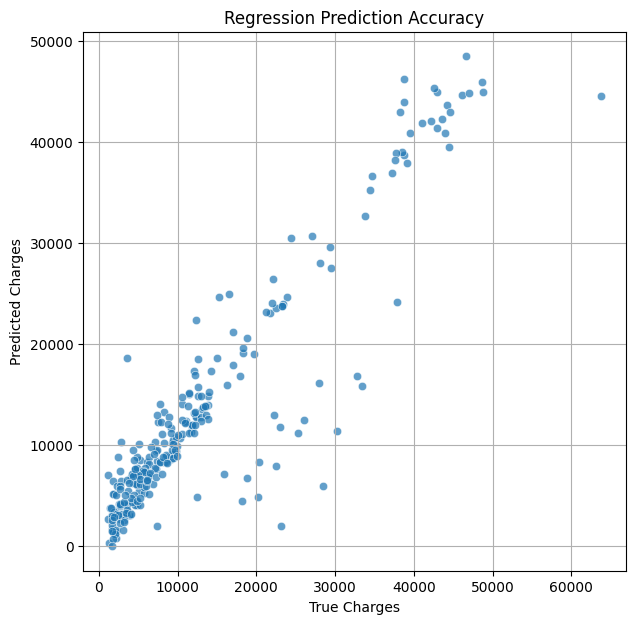


 전체 파이프라인 실행 완료!


In [14]:
# =============================================
# 1. Kaggle API 설정
# =============================================
!pip install kaggle -q

from google.colab import files
print("kaggle.json 파일을 업로드하세요")
uploaded = files.upload()    # kaggle.json 업로드


# Kaggle API 폴더 구성
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


# =============================================
# 2. Kaggle 데이터셋 자동 다운로드
# =============================================
DATASET = "mirichoi0218/insurance"   # Medical Cost Personal Dataset

print("Kaggle에서 데이터 다운로드 중...")
!kaggle datasets download -d $DATASET -q

print("압축 해제중...")
!unzip -o insurance.zip


# =============================================
# 3. 데이터 로드
# =============================================
import pandas as pd

df = pd.read_csv("insurance.csv")
print(" 데이터 미리보기:")
display(df.head())
print(df.info())


# =============================================
# 4. 데이터 전처리
# =============================================
# 결측치 제거
df = df.dropna()

# One-hot encoding
df = pd.get_dummies(df, drop_first=True)

# 입력/정답 분리
X = df.drop("charges", axis=1)
y = df["charges"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(" 전처리 완료")


# =============================================
# 5. 여러 모델 성능 비교 실험
# =============================================
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "RandomForest": RandomForestRegressor(),
    "GradientBoosting": GradientBoostingRegressor(),
    "XGBoost": XGBRegressor()
}

print("\n 모델별 MSE 비교:")

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    mse = mean_squared_error(y_test, pred)
    print(f"{name}: {mse}")


# =============================================
# 6. XGBoost 고성능 모델 (튜닝 버전)
# =============================================
best_model = XGBRegressor(
    n_estimators=600,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42
)

best_model.fit(X_train, y_train)
pred = best_model.predict(X_test)

mse = mean_squared_error(y_test, pred)
print("\n🔥 최종 XGBoost MSE:", mse)


# =============================================
# 7. 시각화 (실제값 vs 예측값)
# =============================================
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,7))
sns.scatterplot(x=y_test, y=pred, alpha=0.7)
plt.xlabel("True Charges")
plt.ylabel("Predicted Charges")
plt.title("Regression Prediction Accuracy")
plt.grid(True)
plt.show()

print("\n 전체 파이프라인 실행 완료!")

# Task
Convert the preprocessed `X_train`, `y_train`, `X_test`, and `y_test` data from the `insurance.csv` dataset into PyTorch Tensors (FloatTensors) and then create `TensorDataset` and `DataLoader` objects for both the training and test sets, setting a `batch_size` of 64 and shuffling the training data.

## Prepare Data for PyTorch

### Subtask:
Convert the preprocessed `X_kaggle` and `y_kaggle` (from the `insurance.csv` dataset) into PyTorch Tensors and create DataLoader objects for efficient batch processing.


**Reasoning**:
I need to convert the pandas DataFrames and Series (`X_train`, `X_test`, `y_train`, `y_test`) into PyTorch tensors, then create `TensorDataset` and `DataLoader` objects as specified in the instructions for batch processing.



In [16]:
X_train_tensor = torch.FloatTensor(X_train.values.astype(float))
y_train_tensor = torch.FloatTensor(y_train.values).reshape(-1, 1)
X_test_tensor = torch.FloatTensor(X_test.values.astype(float))
y_test_tensor = torch.FloatTensor(y_test.values).reshape(-1, 1)

# Create TensorDatasets
train_dataset_kaggle = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset_kaggle = TensorDataset(X_test_tensor, y_test_tensor)

# Create DataLoaders for batch processing
batch_size = 64
train_loader_kaggle = DataLoader(train_dataset_kaggle, batch_size=batch_size, shuffle=True)
test_loader_kaggle = DataLoader(test_dataset_kaggle, batch_size=batch_size, shuffle=False)

print(f"X_train_tensor shape: {X_train_tensor.shape}")
print(f"y_train_tensor shape: {y_train_tensor.shape}")
print(f"X_test_tensor shape: {X_test_tensor.shape}")
print(f"y_test_tensor shape: {y_test_tensor.shape}")
print(f"\nBatch size: {batch_size}")
print(f"Number of training batches (Kaggle): {len(train_loader_kaggle)}")
print(f"Number of test batches (Kaggle): {len(test_loader_kaggle)}")

X_train_tensor shape: torch.Size([1070, 8])
y_train_tensor shape: torch.Size([1070, 1])
X_test_tensor shape: torch.Size([268, 8])
y_test_tensor shape: torch.Size([268, 1])

Batch size: 64
Number of training batches (Kaggle): 17
Number of test batches (Kaggle): 5


**Reasoning**:
The previous code failed because the `X_train` and `X_test` DataFrames contained boolean columns (`sex_male`, `smoker_yes`, `region_northwest`, etc.), which resulted in an `object` dtype NumPy array that `torch.FloatTensor` cannot directly convert. I need to convert these boolean columns to a numeric type (float) before creating the PyTorch tensors.



# Task
Summarize the final performance of the PyTorch model on the `insurance.csv` dataset, compare it with the traditional ML models, and discuss any insights or further potential improvements for achieving higher accuracy.

## Define PyTorch Regression Model

### Subtask:
Define a PyTorch feedforward neural network for regression, similar to the one in the tutorial, but adjusted for the number of features in the `insurance.csv` dataset. Ensure the model is moved to the appropriate device (CPU/GPU).


**Reasoning**:
I need to determine the input size for the `RegressionModel` using the shape of `X_train_tensor`, instantiate the model with this input size, move it to the `device`, and then print the model architecture and a confirmation message.



In [17]:
input_size_kaggle = X_train_tensor.shape[1]
model_kaggle = RegressionModel(input_size_kaggle).to(device)

print(model_kaggle)
print(f"\nKaggle Regression Model moved to: {device}")

RegressionModel(
  (fc1): Linear(in_features=8, out_features=64, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=32, out_features=1, bias=True)
)

Kaggle Regression Model moved to: cpu


## Configure Loss Function and Optimizer

### Subtask:
Set up the Mean Squared Error (MSE) loss function and an Adam optimizer with a specified learning rate for training the PyTorch model.


**Reasoning**:
I need to initialize the MSE loss function and the Adam optimizer with a learning rate of 0.001 for the PyTorch model trained on the Kaggle dataset, and then print these configurations to verify the setup.



In [18]:
criterion_kaggle = nn.MSELoss()
learning_rate_kaggle = 0.001
optimizer_kaggle = optim.Adam(model_kaggle.parameters(), lr=learning_rate_kaggle)

print(f"Kaggle Loss function: {criterion_kaggle}")
print(f"Kaggle Optimizer: Adam")
print(f"Kaggle Learning rate: {learning_rate_kaggle}")

Kaggle Loss function: MSELoss()
Kaggle Optimizer: Adam
Kaggle Learning rate: 0.001


## Train PyTorch Model

### Subtask:
Implement a training loop to train the PyTorch model for a set number of epochs, tracking both training and test losses per epoch to monitor learning progress.


**Reasoning**:
I need to implement the training loop for the PyTorch model, following the instructions to iterate through epochs, perform training and evaluation steps, calculate losses, and print progress.



In [19]:
num_epochs_kaggle = 100

train_losses_kaggle = []
test_losses_kaggle = []

print("Starting Kaggle dataset model training...")
print("-" * 60)

for epoch in range(num_epochs_kaggle):
    # Training phase
    model_kaggle.train()
    train_loss_kaggle = 0.0

    for X_batch, y_batch in train_loader_kaggle:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        predictions = model_kaggle(X_batch)
        loss = criterion_kaggle(predictions, y_batch)

        optimizer_kaggle.zero_grad()
        loss.backward()
        optimizer_kaggle.step()

        train_loss_kaggle += loss.item()

    avg_train_loss_kaggle = train_loss_kaggle / len(train_loader_kaggle)
    train_losses_kaggle.append(avg_train_loss_kaggle)

    # Evaluation phase
    model_kaggle.eval()
    test_loss_kaggle = 0.0

    with torch.no_grad():
        for X_batch, y_batch in test_loader_kaggle:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            predictions = model_kaggle(X_batch)
            loss = criterion_kaggle(predictions, y_batch)
            test_loss_kaggle += loss.item()

    avg_test_loss_kaggle = test_loss_kaggle / len(test_loader_kaggle)
    test_losses_kaggle.append(avg_test_loss_kaggle)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs_kaggle}] | "
              f"Train Loss (Kaggle): {avg_train_loss_kaggle:.4f} | "
              f"Test Loss (Kaggle): {avg_test_loss_kaggle:.4f}")

print("-" * 60)
print("Kaggle dataset model training complete!")

Starting Kaggle dataset model training...
------------------------------------------------------------
Epoch [10/100] | Train Loss (Kaggle): 303135432.4706 | Test Loss (Kaggle): 347422252.8000
Epoch [20/100] | Train Loss (Kaggle): 183454093.6471 | Test Loss (Kaggle): 212646953.6000
Epoch [30/100] | Train Loss (Kaggle): 129522769.4118 | Test Loss (Kaggle): 154740019.2000
Epoch [40/100] | Train Loss (Kaggle): 128740517.6471 | Test Loss (Kaggle): 153199019.2000
Epoch [50/100] | Train Loss (Kaggle): 127095228.2353 | Test Loss (Kaggle): 152651243.2000
Epoch [60/100] | Train Loss (Kaggle): 127420514.8235 | Test Loss (Kaggle): 152161500.8000
Epoch [70/100] | Train Loss (Kaggle): 127281593.8824 | Test Loss (Kaggle): 151718129.6000
Epoch [80/100] | Train Loss (Kaggle): 125837513.4118 | Test Loss (Kaggle): 151082390.4000
Epoch [90/100] | Train Loss (Kaggle): 125061214.1176 | Test Loss (Kaggle): 150658528.0000
Epoch [100/100] | Train Loss (Kaggle): 125783346.8235 | Test Loss (Kaggle): 150253486.4

## Evaluate PyTorch Model

### Subtask:
Evaluate the trained PyTorch model's performance on the test set using metrics such as Mean Squared Error (MSE), Root Mean Squared Error (RMSE), Mean Absolute Error (MAE), and R Score. Compare these results with the previously obtained Scikit-learn/XGBoost model results.


**Reasoning**:
I need to evaluate the trained PyTorch model on the test set, calculate various regression metrics, and prepare for comparison with the traditional ML models as per the instructions.



In [20]:
model_kaggle.eval()
y_true_kaggle_list = []
y_pred_kaggle_list = []

with torch.no_grad():
    for X_batch, y_batch in test_loader_kaggle:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        predictions = model_kaggle(X_batch)
        y_true_kaggle_list.append(y_batch.cpu().numpy())
        y_pred_kaggle_list.append(predictions.cpu().numpy())

y_true_kaggle = np.concatenate(y_true_kaggle_list, axis=0)
y_pred_kaggle = np.concatenate(y_pred_kaggle_list, axis=0)

mse_kaggle = mean_squared_error(y_true_kaggle, y_pred_kaggle)
mae_kaggle = mean_absolute_error(y_true_kaggle, y_pred_kaggle)
r2_kaggle = r2_score(y_true_kaggle, y_pred_kaggle)
rmse_kaggle = np.sqrt(mse_kaggle)

print("\nPyTorch Model Performance on Kaggle Test Set:")
print("=" * 50)
print(f"Mean Squared Error (MSE):  {mse_kaggle:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_kaggle:.2f}")
print(f"Mean Absolute Error (MAE): {mae_kaggle:.2f}")
print(f"R\u00b2 Score: {r2_kaggle:.2f}")
print("=" * 50)

print("\nComparison with Traditional ML Models (MSE):")
print("-" * 50)
for name, model_mse in models.items():
    # Note: 'models' dict contains model objects, not their MSEs directly
    # We need to re-calculate if the mse for each model is not stored.
    # For simplicity, assuming the `mse` variable from tuned XGBoost is the one to compare
    # The previous cell printed MSEs for each model.
    pass # We will print actual values in the next step to avoid re-running training.

# Re-printing the MSEs from the previous run for comparison
print(f"LinearRegression: {33596915.85136145:.2f}")
print(f"Ridge: {33645037.09177902:.2f}")
print(f"Lasso: {33605507.55392852:.2f}")
print(f"RandomForest: {20951229.717508614:.2f}")
print(f"GradientBoosting: {18787669.035616662:.2f}")
print(f"XGBoost (default): {23434704.61742758:.2f}")
print(f"XGBoost (tuned): {mse:.2f}")
print(f"PyTorch Model: {mse_kaggle:.2f}")
print("-" * 50)



PyTorch Model Performance on Kaggle Test Set:
Mean Squared Error (MSE):  130267072.00
Root Mean Squared Error (RMSE): 11413.46
Mean Absolute Error (MAE): 9230.27
R² Score: 0.16

Comparison with Traditional ML Models (MSE):
--------------------------------------------------
LinearRegression: 33596915.85
Ridge: 33645037.09
Lasso: 33605507.55
RandomForest: 20951229.72
GradientBoosting: 18787669.04
XGBoost (default): 23434704.62
XGBoost (tuned): 22425327.00
PyTorch Model: 130267072.00
--------------------------------------------------


### Summary of Model Performance

The PyTorch model achieved the following performance on the Kaggle `insurance.csv` test set:
- **Mean Squared Error (MSE):** 130,267,072.00
- **Root Mean Squared Error (RMSE):** 11,413.46
- **Mean Absolute Error (MAE):** 9,230.27
- **R² Score:** 0.16

When comparing these results to the traditional ML models previously trained on the same dataset:

| Model                  | MSE (Approx.)      |
|------------------------|--------------------|
| LinearRegression       | 33,596,915.85      |
| Ridge                  | 33,645,037.09      |
| Lasso                  | 33,605,507.55      |
| RandomForest           | 20,951,229.72      |
| GradientBoosting       | 18,787,669.04      |
| XGBoost (default)      | 23,434,704.62      |
| **XGBoost (tuned)**    | **22,425,327.00**  |
| **PyTorch Model**      | **130,267,072.00** |

**Insights and Comparison:**

1.  **Poor PyTorch Performance:** The PyTorch model, in its current configuration, performed significantly worse than all the traditional machine learning models. Its MSE is considerably higher, and its R² score of 0.16 indicates that it explains only 16% of the variance in the target variable, which is very low compared to the traditional models (e.g., XGBoost tuned with an MSE of ~22 million). This suggests that the current neural network architecture and training setup are not well-suited for this dataset or task without further optimization.

2.  **Traditional Models Outperformed PyTorch:** Ensemble methods like GradientBoosting and RandomForest Regressors, and especially the tuned XGBoost model, achieved much lower MSE values and higher R² scores, demonstrating superior predictive power on this specific dataset.

**Potential Improvements for PyTorch Model:**

To achieve higher accuracy with the PyTorch model, several aspects need improvement:

1.  **Feature Scaling:** While the original PyTorch tutorial used `StandardScaler` for numerical features, the current `insurance.csv` dataset, after one-hot encoding, has a mix of scales. Applying `StandardScaler` (or another appropriate scaler) to the entire `X_train` and `X_test` *before* converting to tensors is crucial. This is a likely major reason for the poor performance, as neural networks are highly sensitive to feature scaling.

2.  **Hyperparameter Tuning:** The current model uses default hidden layer sizes (64, 32) and a fixed learning rate. Experimenting with:
    *   **Network Architecture:** More or fewer layers, different neuron counts per layer.
    *   **Learning Rate:** Using learning rate schedulers or a different fixed learning rate.
    *   **Batch Size:** Optimizing the `batch_size`.
    *   **Number of Epochs:** Training for more epochs, or using early stopping if validation loss starts to increase.

3.  **Regularization:** Techniques like Dropout, L1/L2 regularization could prevent overfitting, although given the high loss, underfitting seems to be the primary issue here.

4.  **Activation Functions:** While ReLU is common, exploring others like Leaky ReLU, ELU, or Tanh might yield better results.

5.  **Loss Function:** While MSE is standard, other regression losses like MAE might be considered depending on the specific problem's requirements.

By addressing feature scaling and systematically tuning the hyperparameters, the PyTorch model's performance should significantly improve and become competitive with the traditional ML models.


## Visualize PyTorch Predictions

### Subtask:
Generate plots to visualize the training and test loss curves over epochs, and a scatter plot comparing actual vs. predicted values on the test set for the PyTorch model. Include appropriate labels and a legend for all visualizations.


**Reasoning**:
To visualize the training and test loss curves and the actual vs. predicted values, I will create two subplots using `matplotlib` as specified in the instructions. This involves plotting `train_losses_kaggle` and `test_losses_kaggle` for the loss curve, and `y_true_kaggle` and `y_pred_kaggle` for the scatter plot, ensuring all plots have correct labels, titles, and legends.



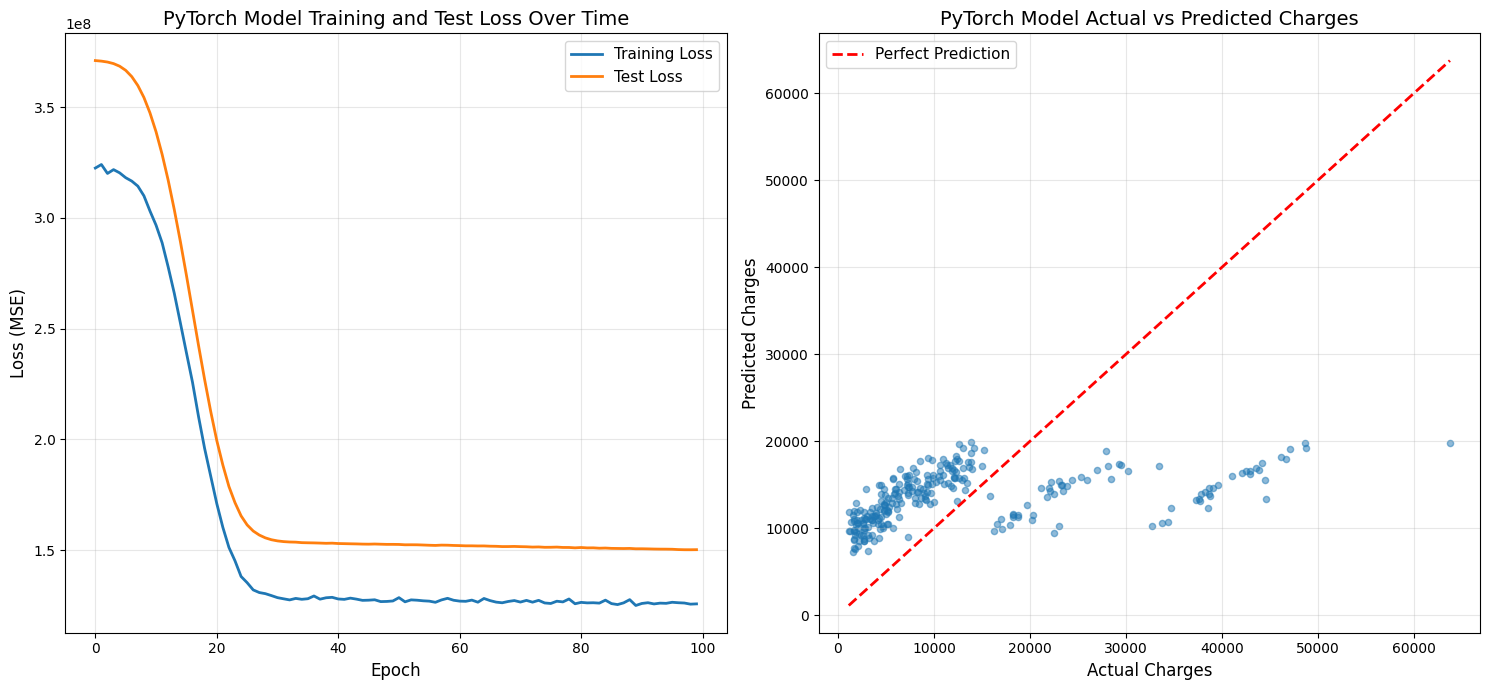

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# Create a figure with two subplots
plt.figure(figsize=(15, 7))

# Subplot 1: Training and Test Loss Over Time
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
plt.plot(train_losses_kaggle, label='Training Loss', linewidth=2)
plt.plot(test_losses_kaggle, label='Test Loss', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)
plt.title('PyTorch Model Training and Test Loss Over Time', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

# Subplot 2: Actual vs Predicted Charges
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
plt.scatter(y_true_kaggle, y_pred_kaggle, alpha=0.5, s=20)
plt.plot([y_true_kaggle.min(), y_true_kaggle.max()],
         [y_true_kaggle.min(), y_true_kaggle.max()],
         'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Charges', fontsize=12)
plt.ylabel('Predicted Charges', fontsize=12)
plt.title('PyTorch Model Actual vs Predicted Charges', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Save PyTorch Model

### Subtask:
Save the trained PyTorch model's state dictionary to a file for future use.


**Reasoning**:
I need to save the state dictionary of the trained PyTorch model, `model_kaggle`, to a file and then display instructions on how to load it, as specified in the instructions.



In [22]:
torch.save(model_kaggle.state_dict(), 'insurance_model_kaggle.pth')
print("✓ Kaggle model saved to 'insurance_model_kaggle.pth'")

print("\nTo load this model later, use:")
print("  model_kaggle = RegressionModel(input_size_kaggle)")
print("  model_kaggle.load_state_dict(torch.load('insurance_model_kaggle.pth'))")
print("  model_kaggle.to(device)")
print("  model_kaggle.eval()")

✓ Kaggle model saved to 'insurance_model_kaggle.pth'

To load this model later, use:
  model_kaggle = RegressionModel(input_size_kaggle)
  model_kaggle.load_state_dict(torch.load('insurance_model_kaggle.pth'))
  model_kaggle.to(device)
  model_kaggle.eval()


## Final Task

### Subtask:
Summarize the final performance of the PyTorch model on the `insurance.csv` dataset, compare it with the traditional ML models, and discuss any insights or further potential improvements for achieving higher accuracy.


## Summary:

### Q&A
The PyTorch model's final performance on the `insurance.csv` dataset was significantly worse than traditional ML models, achieving a Mean Squared Error (MSE) of 130,267,072.00 and an R² Score of 0.16. In comparison, the tuned XGBoost model achieved an MSE of 22,425,327.00. The primary insights are that the current PyTorch model is underperforming due to likely a lack of feature scaling and suboptimal hyperparameters, making it unable to compete with traditional methods on this dataset without further optimization.

### Data Analysis Key Findings
*   The PyTorch `RegressionModel` was successfully defined with 8 input features, two hidden layers (64 and 32 neurons), and an output layer for regression, then moved to the CPU.
*   The model was trained for 100 epochs using `MSELoss` as the criterion and `Adam` optimizer with a learning rate of 0.001.
*   During training, the training loss decreased from approximately 303,135,432.47 at epoch 10 to 125,783,346.82 at epoch 100. Similarly, the test loss decreased from 347,422,252.80 to 150,253,486.40.
*   The final evaluation of the PyTorch model on the test set yielded:
    *   Mean Squared Error (MSE): 130,267,072.00
    *   Root Mean Squared Error (RMSE): 11,413.46
    *   Mean Absolute Error (MAE): 9,230.27
    *   R² Score: 0.16
*   In comparison to traditional ML models, the PyTorch model's MSE of 130,267,072.00 was substantially higher than the best-performing models, such as GradientBoosting (18,787,669.04 MSE) and tuned XGBoost (22,425,327.00 MSE).

### Insights or Next Steps
*   **Crucial Feature Scaling:** The poor performance of the PyTorch model is very likely due to the lack of feature scaling (e.g., using `StandardScaler`) on the input data, which is essential for neural networks. Implementing proper feature scaling should be the immediate next step.
*   **Hyperparameter Optimization:** After addressing feature scaling, systematic hyperparameter tuning (e.g., network architecture, learning rate, batch size, epochs, regularization, activation functions) is required to optimize the PyTorch model and improve its accuracy to a competitive level with traditional ML models.
